# Wildfire Burn-Scar Segmentation with Prithvi-EO

**Fine-tuning NASA/IBM's Prithvi-EO-1.0-100M geospatial foundation model to map wildfire burn scars from satellite imagery.**

This notebook walks through the held-out results and the key modeling findings. It reads precomputed predictions (no GPU needed) — the training/inference code lives in `src/` and `run_*.py`.

- **Encoder:** Prithvi-EO-1.0-100M (ViT, pretrained by IBM/NASA on HLS), frozen, with an FPN decoder.
- **Imagery:** Harmonized Landsat-Sentinel (HLS) surface reflectance, 30 m, via NASA `earthaccess`.
- **Labels:** bi-temporal dNBR (pre vs post-fire NBR; burn = dNBR > 0.10).
- **Evaluation:** three held-out fires the model never trained on — Woolsey, Thomas (SoCal coastal chaparral) and East Troublesome (Colorado Rockies).
- **Honest methods:** the decision threshold is fixed at 0.5 and was *never* tuned on the test fires; the brightness correction and water mask use only training-fire statistics / physics — no test-set leakage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Resolve repo root whether run from repo root or notebooks/
ROOT = Path.cwd()
if not (ROOT / "data/predictions").exists() and (ROOT.parent / "data/predictions").exists():
    ROOT = ROOT.parent
PRED_DIR = ROOT / "data/predictions"

FIRES = {
    "woolsey_fire_2018":     "Woolsey Fire (2018) — Malibu / Thousand Oaks, CA",
    "thomas_fire_2017":      "Thomas Fire (2017) — Ventura / Santa Barbara, CA",
    "east_troublesome_2020": "East Troublesome Fire (2020) — Colorado Rockies",
}

def load(name):
    d = np.load(PRED_DIR / f"{name}.npz")
    return {k: d[k] for k in d.files}

def metrics(pred, true):
    p, t = pred.astype(bool), true.astype(bool)
    tp = int((p & t).sum()); fp = int((p & ~t).sum()); fn = int((~p & t).sum())
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    iou  = tp / (tp + fp + fn) if tp + fp + fn else 0.0
    return prec, rec, iou

def rgb(image):
    """Build a display RGB from the normalized HLS bands [B02,B03,B04,B8A,B11,B12]."""
    out = np.dstack([image[2], image[1], image[0]]).astype(np.float32)  # R=B04,G=B03,B=B02
    for i in range(3):
        ch = out[..., i]
        lo, hi = np.nanpercentile(ch, 2), np.nanpercentile(ch, 98)
        out[..., i] = np.clip((ch - lo) / (hi - lo + 1e-6), 0, 1)
    return np.nan_to_num(out, nan=0.0)

print("predictions:", [f.name for f in sorted(PRED_DIR.glob('*.npz'))])

predictions: ['east_troublesome_2020.npz', 'thomas_fire_2017.npz', 'woolsey_fire_2018.npz']


## Held-out performance

Precision / Recall / IoU on the three fires the model never saw, at the deployed 0.5 threshold (open water excluded via NDWI — see below).

In [2]:
rows, raw = [], []
for name, label in FIRES.items():
    d = load(name)
    p, r, i = metrics(d["pred_mask"], d["true_mask"])
    raw.append((p, r, i))
    rows.append({"Fire": label.split(" — ")[0], "Precision": f"{p:.0%}", "Recall": f"{r:.0%}", "IoU": f"{i:.0%}"})
macro = np.mean(raw, axis=0)
rows.append({"Fire": "— Macro average —", "Precision": f"{macro[0]:.0%}", "Recall": f"{macro[1]:.0%}", "IoU": f"{macro[2]:.0%}"})
pd.DataFrame(rows)

,Fire,Precision,Recall,IoU
0,Woolsey Fire (2018),76%,94%,73%
1,Thomas Fire (2017),96%,71%,69%
2,East Troublesome Fire (2020),56%,80%,49%
3,— Macro average —,76%,82%,64%


## Visual results

For each fire: **HLS post-fire RGB** · **dNBR burn severity** · **ground truth** (dNBR > 0.10) · **model prediction**. All panels share the same pixel grid, so overlays line up exactly.

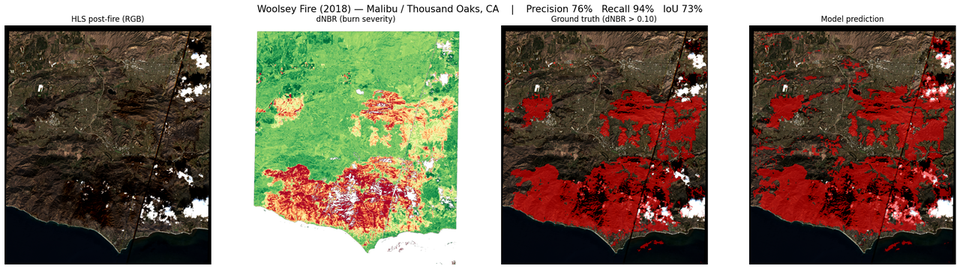

In [3]:
def show_fire(name):
    d = load(name)
    img, pred, true, dnbr = d["image"], d["pred_mask"], d["true_mask"], d["dnbr"]
    p, r, i = metrics(pred, true)
    base = rgb(img)
    fig, ax = plt.subplots(1, 4, figsize=(22, 6))
    ax[0].imshow(base); ax[0].set_title("HLS post-fire (RGB)")
    ax[1].imshow(np.ma.masked_invalid(dnbr), cmap="RdYlGn_r", vmin=-0.2, vmax=0.6)
    ax[1].set_title("dNBR (burn severity)")
    ax[2].imshow(base); ax[2].imshow(np.ma.masked_where(true == 0, true), cmap="autumn", alpha=0.55)
    ax[2].set_title("Ground truth (dNBR > 0.10)")
    ax[3].imshow(base); ax[3].imshow(np.ma.masked_where(pred == 0, pred), cmap="autumn", alpha=0.55)
    ax[3].set_title("Model prediction")
    for a in ax: a.axis("off")
    fig.suptitle(f"{FIRES[name]}    |    Precision {p:.0%}   Recall {r:.0%}   IoU {i:.0%}", fontsize=15)
    plt.tight_layout(); plt.show()

show_fire("woolsey_fire_2018")

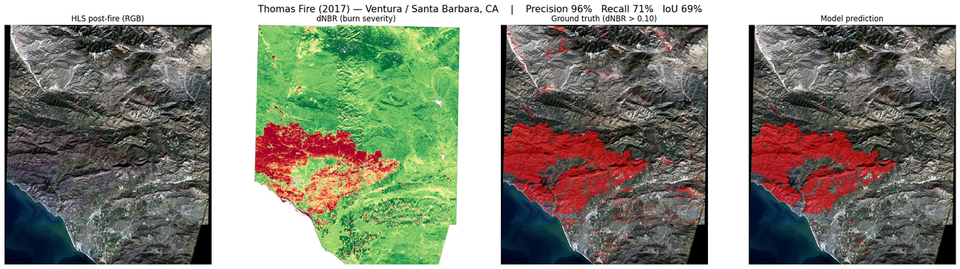

In [4]:
show_fire("thomas_fire_2017")

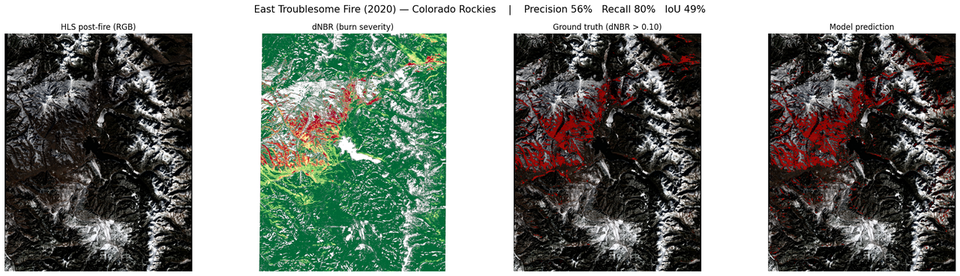

In [5]:
show_fire("east_troublesome_2020")

## Key finding: HLS reflectance is darker than the encoder expects

The model originally **flooded** burn predictions across each scene (Woolsey precision ~0.53, IoU ~0.53). Investigating why led to the central result of this project:

**HLS surface reflectance (LaSRC atmospheric correction + BRDF) runs ~1.4–1.9× darker than the HLS distribution Prithvi-EO was pretrained on** — most strongly in the visible bands. Healthy vegetation reads NIR ≈ 0.13–0.18 where ≈ 0.30–0.45 is expected. Fed to the *frozen* encoder, this dark input mimics the low-NIR signature of char, so the model labels too much as burned.

The fix is a fixed per-band **brightness gain** (calibrated so the pooled *training*-fire median reflectance matches the Prithvi pretraining mean — no test data, no labels), applied before normalization. Effect on held-out fires:

| | Woolsey IoU | East Troublesome IoU | Thomas IoU | **Macro IoU** |
|---|---|---|---|---|
| original (no gain) | 0.526 | 0.488 | 0.602 | **0.539** |
| **+ brightness gain (deployed)** | **0.729** | 0.489 | **0.688** | **0.635** |

Woolsey precision 0.53 → 0.76; Thomas precision 0.70 → 0.96. Full investigation in the [README](../README.md#the-over-prediction-investigation).

## Fine-tune comparison (pending AWS run)

Once the Prithvi-EO-2.0-300M fine-tune completes on AWS, the cells below load the training
histories and compare frozen-encoder (1.0) vs fine-tuned (2.0) on the held-out test fires.
Run `eval_sweep.py` first to get the metrics, then execute these cells.


In [ ]:
import torch, xarray as xr
from pathlib import Path
from src.data import _restore_crs, load_config
from src.model import BurnScarModel
from src.utils import get_device
from src.train import compute_metrics
from run_inference import run_inference

FROZEN_DIR    = Path('checkpoints/balanced_chaparral')
FINETUNED_DIR = Path('checkpoints/finetune_v2')

def load_history(ckpt_dir):
    return torch.load(ckpt_dir / 'history.pt', map_location='cpu', weights_only=False)

frozen_hist   = load_history(FROZEN_DIR)
finetuned_hist = load_history(FINETUNED_DIR)

ft_cfg = load_config('configs/finetune_config.yaml')
unfreeze_epoch = ft_cfg['model']['unfreeze_after_epoch']

# --- training curves ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for hist, label, color in [
    (frozen_hist,   'Frozen 1.0',    '#2196F3'),
    (finetuned_hist,'Fine-tuned 2.0', '#F44336'),
]:
    ep = range(1, len(hist['train']) + 1)
    axes[0].plot(ep, [m['loss']     for m in hist['val']], '-', color=color, label=label, lw=2)
    axes[0].plot(ep, [m['loss']     for m in hist['train']], '-', color=color, alpha=0.35, lw=1)
    axes[1].plot(ep, [m['mean_iou'] for m in hist['val']], '-', color=color, label=label, lw=2)
    axes[1].plot(ep, [m['mean_iou'] for m in hist['train']], '-', color=color, alpha=0.35, lw=1)

axes[1].axvline(x=unfreeze_epoch + 0.5, color='#F44336', ls='--', alpha=0.5, label='Encoder unfrozen')
for ax, title, ylabel in zip(axes, ['Validation Loss', 'Validation IoU'], ['Loss', 'Mean IoU']):
    ax.set(xlabel='Epoch', ylabel=ylabel, title=title); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Frozen (1.0) vs Fine-tuned (2.0) Prithvi Encoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/frozen_vs_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# --- held-out test-fire comparison ---
# Run scripts/eval_sweep.py first, then paste results here, or run inline:
cfg = load_config('configs/train_config.yaml')
cache = Path(cfg['data']['cache_dir'])
bands = cfg['data']['bands']
ps    = cfg['data']['patch_size']
dnbr_t = cfg['data'].get('dnbr_threshold', 0.10)
device = get_device()

def eval_checkpoint(ckpt_path, config_path='configs/train_config.yaml'):
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    ver   = state.get('config', {}).get('model', {}).get('prithvi_version', '1.0')
    c     = load_config(config_path)
    model = BurnScarModel(num_classes=c['model']['num_classes'],
                          in_channels=c['model']['in_channels'], prithvi_version=ver)
    model.load_state_dict(state['model_state_dict'])
    model.to(device).eval()
    results = {}
    for fire in ['woolsey_fire_2018', 'east_troublesome_2020', 'thomas_fire_2017']:
        pre  = _restore_crs(xr.open_dataset(cache / f'{fire}_pre.nc',  engine='h5netcdf'))
        post = _restore_crs(xr.open_dataset(cache / f'{fire}_post.nc', engine='h5netcdf')).rio.reproject_match(pre)
        pred, true, _ = run_inference(model, post, pre, bands=bands,
                                       patch_size=ps, device=device, dnbr_threshold=dnbr_t,
                                       prithvi_version=ver)
        tp = int(((pred==1)&(true==1)).sum())
        fp = int(((pred==1)&(true==0)).sum())
        fn = int(((pred==0)&(true==1)).sum())
        results[fire] = dict(precision=tp/(tp+fp) if tp+fp else 0,
                              recall=tp/(tp+fn)   if tp+fn else 0,
                              iou=tp/(tp+fp+fn)   if tp+fp+fn else 0)
    return results

frozen_r   = eval_checkpoint(FROZEN_DIR    / 'best_model.pt')
finetuned_r = eval_checkpoint(FINETUNED_DIR / 'best_model.pt', 'configs/finetune_config.yaml')

print(f"{'Fire':<26} {'Frozen 1.0':>22} {'Fine-tuned 2.0':>22}")
print(f"{'':26} {'P / R / IoU':>22} {'P / R / IoU':>22}")
print('-' * 72)
for fire in frozen_r:
    f, t = frozen_r[fire], finetuned_r[fire]
    print(f"{fire:<26} {f['precision']:6.3f}/{f['recall']:6.3f}/{f['iou']:6.3f}  "
          f"    {t['precision']:6.3f}/{t['recall']:6.3f}/{t['iou']:6.3f}")
macro_f = {m: np.mean([v[m] for v in frozen_r.values()])   for m in ['precision','recall','iou']}
macro_t = {m: np.mean([v[m] for v in finetuned_r.values()]) for m in ['precision','recall','iou']}
print('-' * 72)
print(f"{'MACRO':<26} {macro_f['precision']:6.3f}/{macro_f['recall']:6.3f}/{macro_f['iou']:6.3f}  "
      f"    {macro_t['precision']:6.3f}/{macro_t['recall']:6.3f}/{macro_t['iou']:6.3f}")


## Methods & honesty notes

- **No test-set leakage.** The 0.5 decision threshold was calibrated on training fires only; the brightness gain uses pooled training-fire medians; the water mask is a physics-based spectral index (NDWI). None touch the held-out fires.
- **Water exclusion.** Open water makes NBR pure noise (NIR ≈ SWIR ≈ 0), so both the model and the dNBR label spuriously flag it as burned. An NDWI mask removes it deterministically.
- **What didn't work (documented honestly).** Asymmetric loss, threshold re-tuning, encoder fine-tuning, and hard-negative data all failed to beat the frozen+gain model — the limitation was the *input domain*, not the objective. See the analysis writeup.

## Limitations & future work

- Residual over-prediction remains on dry chaparral hillsides (Woolsey precision ~0.76).
- Encoder fine-tuning overfit on a small (~19-fire) training set; the set has since been expanded to **37 geographically diverse fires**, and a GPU fine-tune (with layer-wise LR decay + a fire-based validation split) is set up to run on cloud hardware.